### Pacotes importados

In [6]:
using LinearAlgebra
using Printf
using Plots
using ForwardDiff

## Chapter 11: Descent methods and line search

### Algorithm 11.2: Initialization of the exact line search 

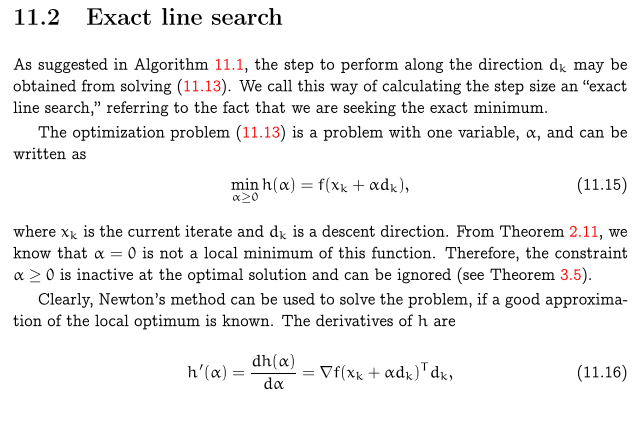

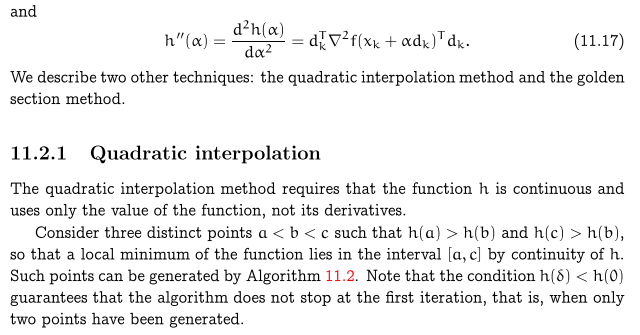

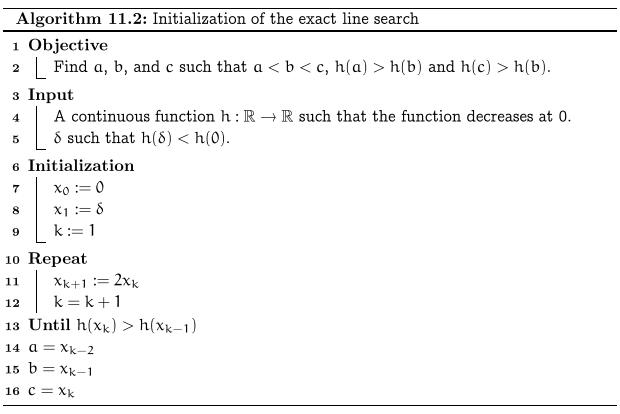

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

  k                x_k             h(x_k)
  0  +0.0000000000E+00  -8.3229367309E-01
  1  +1.0000000000E-01  -1.0601768197E+00
  2  +2.0000000000E-01  -1.2947024580E+00
  3  +4.0000000000E-01  -1.7697449173E+00
  4  +8.0000000000E-01  -2.6382225539E+00
  5  +1.6000000000E+00  -3.2283302988E+00
  6  +3.2000000000E+00  +2.4362866908E+00

Intervalo encontrado:
a = 0.8
b = 1.6
c = 3.2

Verificação:
a < b < c ? true
h(a) > h(b) ? true
h(c) > h(b) ? true


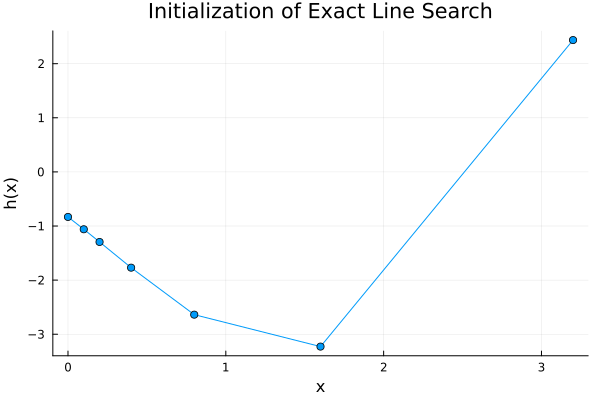

In [2]:
h(x) = (2 + x) * cos(2 + x)

delta = 0.1

if h(delta) >= h(0)
    error("Escolha outro δ, pois h(δ) não é menor que h(0).")
end

x0 = 0.0
x1 = delta
k = 1

xs = [x0, x1]
hs = [h(x0), h(x1)]

@printf("%3s %18s %18s\n", "k", "x_k", "h(x_k)")
@printf("%3d %+18.10E %+18.10E\n", 0, x0, h(x0))
@printf("%3d %+18.10E %+18.10E\n", 1, x1, h(x1))

while h(xs[end]) <= h(xs[end-1])
    xnew = 2 * xs[end]
    push!(xs, xnew)
    push!(hs, h(xnew))

    k += 1
    @printf("%3d %+18.10E %+18.10E\n", k, xnew, h(xnew))
end

a = xs[end-2]
b = xs[end-1]
c = xs[end]

println("\nIntervalo encontrado:")
println("a = ", a)
println("b = ", b)
println("c = ", c)

println("\nVerificação:")
println("a < b < c ? ", a < b < c)
println("h(a) > h(b) ? ", h(a) > h(b))
println("h(c) > h(b) ? ", h(c) > h(b))

plot(
    xs,
    hs,
    marker = :circle,
    xlabel = "x",
    ylabel = "h(x)",
    title = "Initialization of Exact Line Search",
    legend = false
)

### Algorithm 11.3: Exact line search: quadratic interpolation

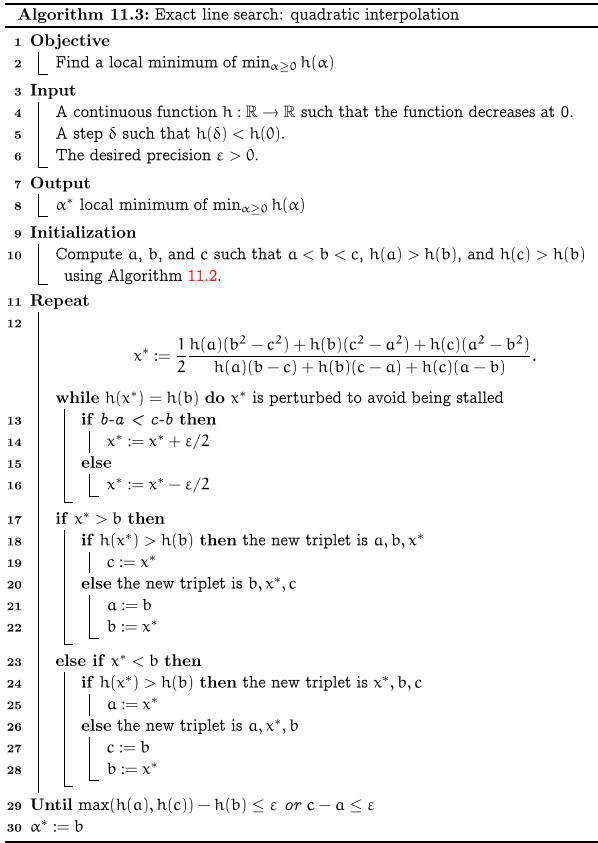

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

  k                 x1                 x2               f(x)           ||grad||              alpha
  0  +9.0000000000E+00  +1.0000000000E+00  +4.5000000000E+01  +1.2727922061E+01  +2.0000000000E-01
  1  +7.2000000000E+00  -8.0000000000E-01  +2.8800000000E+01  +1.0182337649E+01  +2.0000000000E-01
  2  +5.7600000000E+00  +6.4000000000E-01  +1.8432000000E+01  +8.1458701193E+00  +2.0000000000E-01
  3  +4.6080000000E+00  -5.1200000000E-01  +1.1796480000E+01  +6.5166960954E+00  +2.0000000000E-01
  4  +3.6864000000E+00  +4.0960000000E-01  +7.5497472000E+00  +5.2133568763E+00  +2.0000000000E-01
  5  +2.9491200000E+00  -3.2768000000E-01  +4.8318382080E+00  +4.1706855011E+00  +2.0000000000E-01
  6  +2.3592960000E+00  +2.6214400000E-01  +3.0923764531E+00  +3.3365484009E+00  +2.0000000000E-01
  7  +1.8874368000E+00  -2.0971520000E-01  +1.9791209300E+00  +2.6692387207E+00  +2.0000000000E-01
  8  +1.5099494400E+00  +1.6777216000E-01  +1.2666373952E+00  +2.1353909765E+00  +2.0000000000E-01
  9  +1.20

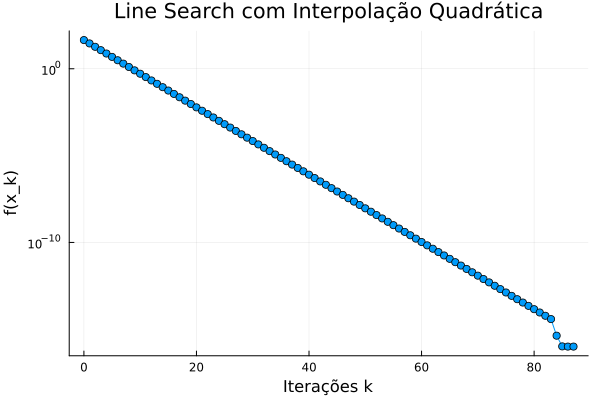

In [4]:
f(x) = 0.5*x[1]^2 + 4.5*x[2]^2

grad_f(x) = [
    x[1]
    9*x[2]
]

function initialize_line_search(h, delta)
    xs = [0.0, delta]

    if h(xs[2]) >= h(xs[1])
        error("h(delta) não é menor que h(0). Escolha delta menor.")
    end

    while h(xs[end]) <= h(xs[end-1])
        push!(xs, 2*xs[end])

        if length(xs) > 100
            error("Falha na inicialização da busca linear.")
        end
    end

    return xs[end-2], xs[end-1], xs[end]
end

function quadratic_interpolation(h, delta, epsilon; maxiter=100)
    a, b, c = initialize_line_search(h, delta)

    for it in 1:maxiter
        ha, hb, hc = h(a), h(b), h(c)

        num = ha*(b^2 - c^2) + hb*(c^2 - a^2) + hc*(a^2 - b^2)
        den = ha*(b - c) + hb*(c - a) + hc*(a - b)

        if abs(den) < 1e-14
            return b
        end

        xstar = 0.5*num/den

        if !(a < xstar < c) || !isfinite(xstar)
            xstar = (a + c)/2
        end

        if abs(xstar - b) < 1e-14
            xstar += (c - b > b - a ? epsilon/2 : -epsilon/2)
        end

        hx = h(xstar)

        if xstar > b
            if hx > hb
                c = xstar
            else
                a = b
                b = xstar
            end
        else
            if hx > hb
                a = xstar
            else
                c = b
                b = xstar
            end
        end

        if max(h(a), h(c)) - h(b) <= epsilon || c - a <= epsilon
            return b
        end
    end

    return b
end

x = [9.0, 1.0]
epsilon = 1e-8
delta = 1e-4
maxiter = 100

ks = Int[]
values = Float64[]

@printf("%3s %18s %18s %18s %18s %18s\n", "k", "x1", "x2", "f(x)", "||grad||", "alpha")

for k in 0:maxiter
    g = grad_f(x)
    normg = norm(g)

    push!(ks, k)
    push!(values, max(f(x), 1e-16))

    if normg <= epsilon
        break
    end

    d = -g
    h(alpha) = f(x + alpha*d)

    alpha = quadratic_interpolation(h, delta, epsilon)

    @printf("%3d %+18.10E %+18.10E %+18.10E %+18.10E %+18.10E\n",
        k, x[1], x[2], f(x), normg, alpha)

    x = x + alpha*d
end

println("\nSolução aproximada:")
println("x* = ", x)
println("f(x*) = ", f(x))
println("gradiente = ", grad_f(x))
println("||grad|| = ", norm(grad_f(x)))

plot(
    ks,
    values,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "f(x_k)",
    title = "Line Search com Interpolação Quadrática",
    legend = false,
    yscale = :log10
)

### Algorithm 11.5: Line search

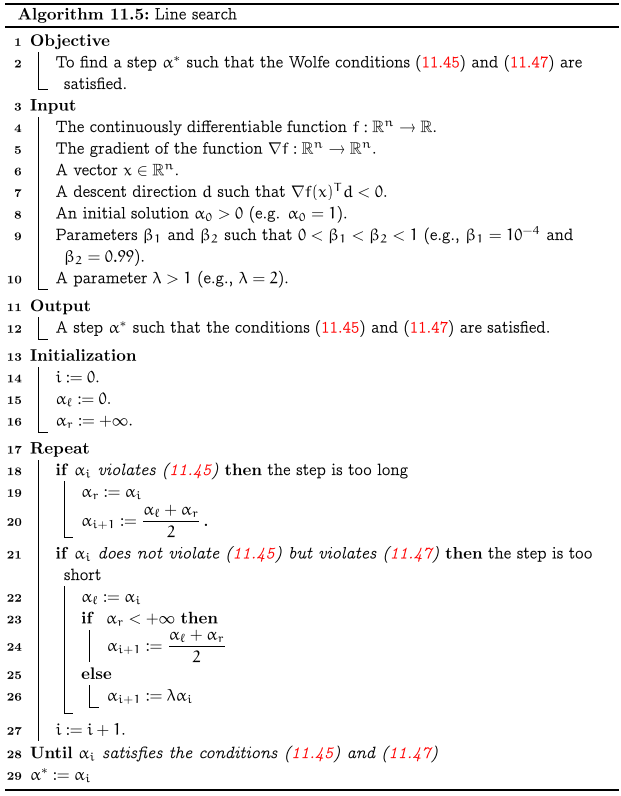

Example 11.2: $f(x) = \frac{1}{2} x_1^2 + \frac{9}{2} x_2^2$.

In [5]:
# Função do exemplo 11.2
f(x) = 0.5*x[1]^2 + 4.5*x[2]^2

# Gradiente
grad_f(x) = [
    x[1]
    9*x[2]
]

function line_search_wolfe(f, grad_f, x, d;
                           alpha0 = 1.0,
                           beta1 = 1e-4,
                           beta2 = 0.99,
                           lambda = 2.0,
                           maxiter = 50)

    alpha = alpha0
    alpha_l = 0.0
    alpha_r = Inf

    fx = f(x)
    gx = grad_f(x)
    gd = dot(gx, d)

    if gd >= 0
        error("d não é direção de descida.")
    end

    for i in 0:maxiter
        xnew = x + alpha*d

        # Condição de Armijo / Wolfe 1
        wolfe1 = f(xnew) <= fx + beta1*alpha*gd

        # Condição de curvatura / Wolfe 2
        wolfe2 = dot(grad_f(xnew), d) >= beta2*gd

        @printf("%3d  alpha = %+14.8E  Wolfe1 = %s  Wolfe2 = %s\n",
                i, alpha, string(wolfe1), string(wolfe2))

        if wolfe1 && wolfe2
            return alpha
        end

        if !wolfe1
            alpha_r = alpha
            alpha = (alpha_l + alpha_r)/2
        else
            alpha_l = alpha

            if isfinite(alpha_r)
                alpha = (alpha_l + alpha_r)/2
            else
                alpha = lambda*alpha
            end
        end
    end

    return alpha
end

# Ponto inicial
x = [9.0, 1.0]

# Direção de descida
g = grad_f(x)
d = -g

alpha = line_search_wolfe(f, grad_f, x, d)

println("\nPasso encontrado:")
println("alpha = ", alpha)

xnew = x + alpha*d

println("\nNovo ponto:")
println("x_new = ", xnew)
println("f(x_new) = ", f(xnew))
println("gradiente = ", grad_f(xnew))

  0  alpha = +1.00000000E+00  Wolfe1 = false  Wolfe2 = true
  1  alpha = +5.00000000E-01  Wolfe1 = false  Wolfe2 = true
  2  alpha = +2.50000000E-01  Wolfe1 = true  Wolfe2 = true

Passo encontrado:
alpha = 0.25

Novo ponto:
x_new = [6.75, -1.25]
f(x_new) = 29.8125
gradiente = [6.75, -11.25]


### Algorithm 11.6: Steepest descent

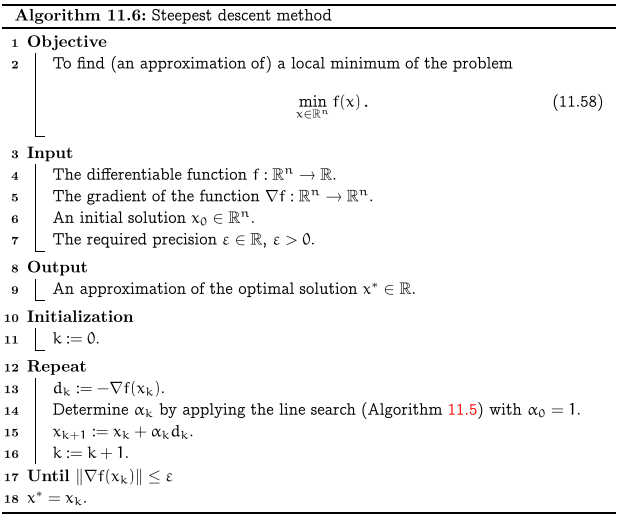

Test in the Rosenbrock function

    k                 x1                 x2               f(x)           ||grad||              alpha
    0  -1.2000000000E+00  +1.0000000000E+00  +2.4200000000E+01  +2.3286768775E+02  +9.7656250000E-04
  100  +9.5812582582E-01  +9.1795629314E-01  +1.7536846558E-03  +6.5772157296E-02  +1.9531250000E-03
  200  +9.6194486231E-01  +9.2537950596E-01  +1.4483664598E-03  +9.2487126732E-02  +1.9531250000E-03
  300  +9.6540049682E-01  +9.3196269006E-01  +1.1972511430E-03  +5.5968021453E-02  +1.9531250000E-03
  400  +9.6846934865E-01  +9.3797413762E-01  +9.9435219933E-04  +7.9473819138E-02  +1.9531250000E-03
  500  +9.7126685062E-01  +9.4331487866E-01  +8.2579115554E-04  +4.1179774832E-02  +1.9531250000E-03
  600  +9.7377178488E-01  +9.4819981228E-01  +6.8801961021E-04  +4.0615215171E-02  +1.9531250000E-03
  700  +9.7603934999E-01  +9.5260997847E-01  +5.7429622617E-04  +3.2352960228E-02  +1.9531250000E-03
  800  +9.7808622172E-01  +9.5664457796E-01  +4.8022020583E-04  +4.0698801756E-02  +1.95312

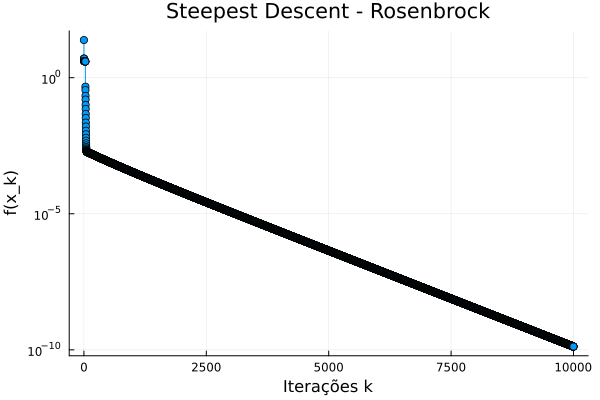

In [7]:
# Função de Rosenbrock
function f(x)
    return 100*(x[2] - x[1]^2)^2 + (1 - x[1])^2
end

# Gradiente calculado automaticamente
grad_f(x) = ForwardDiff.gradient(f, x)

# Line Search - Wolfe
function line_search_wolfe(f, grad_f, x, d;
                           alpha0 = 1.0,
                           beta1 = 1e-4,
                           beta2 = 0.99,
                           lambda = 2.0,
                           maxiter = 50)

    alpha = alpha0
    alpha_l = 0.0
    alpha_r = Inf

    fx = f(x)
    gx = grad_f(x)
    gd = dot(gx, d)

    if gd >= 0
        error("d não é direção de descida.")
    end

    for i in 1:maxiter
        xnew = x + alpha*d

        wolfe1 = f(xnew) <= fx + beta1*alpha*gd
        wolfe2 = dot(grad_f(xnew), d) >= beta2*gd

        if wolfe1 && wolfe2
            return alpha
        end

        if !wolfe1
            alpha_r = alpha
            alpha = (alpha_l + alpha_r)/2
        else
            alpha_l = alpha

            if isfinite(alpha_r)
                alpha = (alpha_l + alpha_r)/2
            else
                alpha = lambda*alpha
            end
        end
    end

    return alpha
end

# Dados iniciais
x = [-1.2, 1.0]
epsilon = 1e-8
maxiter = 10000

ks = Int[]
values = Float64[]
gradnorms = Float64[]

@printf("%5s %18s %18s %18s %18s %18s\n",
        "k", "x1", "x2", "f(x)", "||grad||", "alpha")

for k in 0:maxiter
    g = grad_f(x)
    normg = norm(g)

    push!(ks, k)
    push!(values, max(f(x), 1e-16))
    push!(gradnorms, max(normg, 1e-16))

    if normg <= epsilon
        break
    end

    # Direção de maior descida
    d = -g

    # Busca linear com Wolfe
    alpha = line_search_wolfe(f, grad_f, x, d)

    if k % 100 == 0
        @printf("%5d %+18.10E %+18.10E %+18.10E %+18.10E %+18.10E\n",
                k, x[1], x[2], f(x), normg, alpha)
    end

    x = x + alpha*d
end

println("\nSolução aproximada:")
println("x* = ", x)
println("f(x*) = ", f(x))
println("gradiente = ", grad_f(x))
println("||grad|| = ", norm(grad_f(x)))

plot(
    ks,
    values,
    marker = :circle,
    xlabel = "Iterações k",
    ylabel = "f(x_k)",
    title = "Steepest Descent - Rosenbrock",
    legend = false,
    yscale = :log10
)